In [34]:
!pip install prophet

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
# Import Prophet library
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import datetime

In [2]:
df = pd.read_csv("/content/merged_data (3).csv")

In [3]:
# 1. Load your original DataFrame (assuming it has 'date' and 'load')
df['date'] = pd.to_datetime(df['date'])  # Ensure date is datetime
df['load'] = df['load']  # Assuming your target column is 'load'

# 2. Create a Prophet-style dataframe
prophet_df = df.copy()
prophet_df.rename(columns={'date': 'ds', 'load': 'y'}, inplace=True)

# 3. Add Smart Features
# Hour of day
prophet_df['hour'] = prophet_df['ds'].dt.hour

# Day of week (0=Monday, 6=Sunday)
prophet_df['day_of_week'] = prophet_df['ds'].dt.dayofweek

# Weekend flag
prophet_df['is_weekend'] = prophet_df['day_of_week'].isin([5, 6]).astype(int)

# Working hours flag (9am to 6pm)
prophet_df['is_working_hour'] = prophet_df['hour'].between(9, 18).astype(int)

# Month and season
prophet_df['month'] = prophet_df['ds'].dt.month
prophet_df['season'] = prophet_df['month'] % 12 // 3 + 1  # 1=winter, 2=spring, 3=summer, 4=fall

# Holiday flag (basic example, you can expand this list)
us_holidays = pd.to_datetime([
    '2024-01-01', '2024-07-04', '2024-12-25',
    '2025-01-01', '2025-07-04', '2025-12-25'
])
prophet_df['is_holiday'] = prophet_df['ds'].dt.date.isin(us_holidays.date).astype(int)

# Lag features
prophet_df['load_lag_1h'] = prophet_df['y'].shift(1)
prophet_df['load_lag_24h'] = prophet_df['y'].shift(24)

# Rolling average features
prophet_df['load_ma_3h'] = prophet_df['y'].rolling(window=3).mean()
prophet_df['load_ma_24h'] = prophet_df['y'].rolling(window=24).mean()

# Temperature-based features (if temp column exists)
if 'temp' in prophet_df.columns:
    prophet_df['temp_diff'] = prophet_df['temp'].diff()
    prophet_df['temp_deviation'] = prophet_df['temp'] - prophet_df['temp'].mean()

# Solar interaction (if solarenergy column exists)
if 'solarenergy' in prophet_df.columns:
    prophet_df['solar_active'] = prophet_df['solarenergy'] * prophet_df['is_working_hour']

# 4. Drop rows with NaN values caused by shifts, rolling averages, or missing features
prophet_df = prophet_df.dropna().reset_index(drop=True)

# 5. Remove duplicates on 'ds'
prophet_df = prophet_df.drop_duplicates(subset=['ds'])

# 6. Final selection of relevant columns
# Customize this list if you have more features
prophet_df = prophet_df[[
    'ds', 'y', 'hour', 'temp', 'humidity', 'sealevelpressure', 'solarenergy',
    'day_of_week', 'is_weekend', 'is_working_hour', 'month', 'season',
    'is_holiday', 'load_lag_1h', 'load_lag_24h', 'load_ma_3h', 'load_ma_24h',
    'temp_diff', 'temp_deviation', 'solar_active'
]]

# 7. Display prepared DataFrame sample
prophet_df.tail()

,ds,y,hour,temp,humidity,sealevelpressure,solarenergy,day_of_week,is_weekend,is_working_hour,month,season,is_holiday,load_lag_1h,load_lag_24h,load_ma_3h,load_ma_24h,temp_diff,temp_deviation,solar_active
44563,2025-01-31 19:00:00,322488.235911,19,49.9,46.34,1022.3,0.0,4,0,0,1,1,0,329172.699870,335119.506927,326479.378038,310488.444928,-2.7,-11.82544,0.0
44564,2025-01-31 20:00:00,322158.914687,20,47.5,50.81,1022.4,0.0,4,0,0,1,1,0,322488.235911,330001.442708,324606.616823,310161.672927,-2.4,-14.22544,0.0
44565,2025-01-31 21:00:00,316317.876276,21,48.5,41.13,1022.4,0.0,4,0,0,1,1,0,322158.914687,323304.784714,320321.675625,309870.551742,1.0,-13.22544,0.0
44566,2025-01-31 22:00:00,299743.669323,22,44.2,55.24,1022.9,0.0,4,0,0,1,1,0,316317.876276,308009.983490,312740.153429,309526.121985,-4.3,-17.52544,0.0
44567,2025-01-31 23:00:00,284053.807734,23,43.0,54.02,1022.6,0.0,4,0,0,1,1,0,299743.669323,289971.488177,300038.451111,309279.551967,-1.2,-18.72544,0.0


In [4]:
# Ensure your datetime is in the correct format
df['ds'] = pd.to_datetime(df['date'])  # Replace 'date' with your datetime column
df['y'] = df['load']  # Replace 'load' with your target variable name

# Hour of day
df['hour'] = df['ds'].dt.hour

# Day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df['ds'].dt.dayofweek

# Weekend flag
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Working hours flag (9am to 6pm)
df['is_working_hour'] = df['hour'].between(9, 18).astype(int)

# Month and season
df['month'] = df['ds'].dt.month
df['season'] = df['month'] % 12 // 3 + 1  # 1=winter, 2=spring, 3=summer, 4=fall

# Holiday flag (you can expand this list)
us_holidays = pd.to_datetime([
    '2024-01-01', '2024-07-04', '2024-12-25',
    '2025-01-01', '2025-07-04', '2025-12-25'
])
df['is_holiday'] = df['ds'].dt.date.isin(us_holidays.date).astype(int)

# Lag features (you can adjust these based on your time resolution)
df['load_lag_1h'] = df['y'].shift(1)
df['load_lag_24h'] = df['y'].shift(24)

# Rolling average features
df['load_ma_3h'] = df['y'].rolling(window=3).mean()
df['load_ma_24h'] = df['y'].rolling(window=24).mean()

# Temp-based features
if 'temp' in df.columns:
    df['temp_diff'] = df['temp'].diff()
    df['temp_deviation'] = df['temp'] - df['temp'].mean()

# Solar interaction
if 'solarenergy' in df.columns:
    df['solar_active'] = df['solarenergy'] * df['is_working_hour']

# Drop rows with NaNs caused by lag/rolling
df = df.dropna().reset_index(drop=True)

# Final columns to use in Prophet (customize this list as needed)
prophet_columns = [
    'ds', 'y', 'hour', 'day_of_week', 'is_weekend', 'is_working_hour',
    'month', 'season', 'is_holiday', 'load_lag_1h', 'load_lag_24h',
    'load_ma_3h', 'load_ma_24h', 'temp_diff', 'temp_deviation', 'solar_active'
]

# Drop any that don’t exist (e.g., temp_diff if temp not present)
prophet_df = df[[col for col in prophet_columns if col in df.columns]]

In [5]:
# Data preparation
# Prophet requires a dataframe with 'ds' (datetime) and 'y' (target) columns
df['date'] = pd.to_datetime(df['date'])

# Create a Prophet dataframe - rename date column to 'ds' as required by Prophet
prophet_df = df.copy()
prophet_df.rename(columns={'date': 'ds', 'load': 'y'}, inplace=True)

# Keep only the relevant columns and drop rows with NaN values
prophet_df = prophet_df[['ds', 'y', 'hour', 'temp', 'humidity', 'sealevelpressure', 'solarenergy']]
prophet_df = prophet_df.dropna()

# Display the prepared dataframe
prophet_df.tail()

,ds,ds,y,y,hour,temp,humidity,sealevelpressure,solarenergy
44563,2025-01-31 19:00:00,2025-01-31 19:00:00,322488.235911,322488.235911,19,49.9,46.34,1022.3,0.0
44564,2025-01-31 20:00:00,2025-01-31 20:00:00,322158.914687,322158.914687,20,47.5,50.81,1022.4,0.0
44565,2025-01-31 21:00:00,2025-01-31 21:00:00,316317.876276,316317.876276,21,48.5,41.13,1022.4,0.0
44566,2025-01-31 22:00:00,2025-01-31 22:00:00,299743.669323,299743.669323,22,44.2,55.24,1022.9,0.0
44567,2025-01-31 23:00:00,2025-01-31 23:00:00,284053.807734,284053.807734,23,43.0,54.02,1022.6,0.0


In [4]:
# Split data into training and testing sets
train_size = int(len(prophet_df) * 0.8)
train_data = prophet_df[:train_size]
test_data = prophet_df[train_size:]

print(f"Training data size: {train_data.shape}")
print(f"Testing data size: {test_data.shape}")

Training data size: (35650, 20)
Testing data size: (8913, 20)


In [5]:
# Initialize and train Prophet model with additional regressors
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

# Add the specified features as regressors
features = ['hour', 'temp', 'humidity', 'sealevelpressure', 'solarenergy']
for feature in features:
    model.add_regressor(feature)

# Fit the model
%time model.fit(train_data)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdwczxaod/vv3nfqna.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdwczxaod/id8a0omo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=55153', 'data', 'file=/tmp/tmpdwczxaod/vv3nfqna.json', 'init=/tmp/tmpdwczxaod/id8a0omo.json', 'output', 'file=/tmp/tmpdwczxaod/prophet_model7bb519nf/prophet_model-20250429170932.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:09:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:10:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


CPU times: user 3.4 s, sys: 280 ms, total: 3.68 s
Wall time: 45.4 s


In [6]:
from prophet import Prophet

# 1. Initialize the Prophet model
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

# 2. Add all features from the prepared DataFrame (except 'ds' and 'y')
for feature in prophet_df.columns:
    if feature not in ['ds', 'y']:
        model.add_regressor(feature)

# 3. Split into training and testing sets (if not done yet)
train_size = int(len(prophet_df) * 0.8)
train_data = prophet_df[:train_size]
test_data = prophet_df[train_size:]

# 4. Remove any duplicate 'ds' rows just to be safe
train_data = train_data.drop_duplicates(subset=['ds'])

# 5. Fit the model
%time model.fit(train_data)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdwczxaod/0vtt5tyv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdwczxaod/wp_ycdab.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99977', 'data', 'file=/tmp/tmpdwczxaod/0vtt5tyv.json', 'init=/tmp/tmpdwczxaod/wp_ycdab.json', 'output', 'file=/tmp/tmpdwczxaod/prophet_model3o3hs_ed/prophet_model-20250429171058.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:10:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:11:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


CPU times: user 4.87 s, sys: 224 ms, total: 5.1 s
Wall time: 24.7 s


In [7]:
# 1. Prepare the future DataFrame from the test set
# Make a fresh copy of test data, drop index for safety
future = test_data.copy().reset_index(drop=True)

# 2. Ensure future DataFrame has all required regressors
# Prophet expects all the same regressors used during training to be present
# (they're already there from the feature engineering step)

# 3. Make Predictions
forecast = model.predict(future)

# 4. Create a clean results DataFrame
results = pd.DataFrame({
    'ds': future['ds'],            # Date/time
    'actual': future['y'],          # True load values
    'predicted': forecast['yhat']   # Model's predicted load
})

# 5. Handle any NaN values (e.g., if model failed for some timestamps)
results = results.dropna()

# 6. Display sample predictions
results.tail()


,ds,actual,predicted
8908,2025-01-31 19:00:00,322488.235911,328059.780566
8909,2025-01-31 20:00:00,322158.914687,322558.889904
8910,2025-01-31 21:00:00,316317.876276,308045.529675
8911,2025-01-31 22:00:00,299743.669323,292806.919397
8912,2025-01-31 23:00:00,284053.807734,281298.682223


In [8]:
# Evaluate model performance
if not results.empty:
    mae = mean_absolute_error(results['actual'], results['predicted'])
    rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
    r2 = r2_score(results['actual'], results['predicted'])

    # Calculate percent error
    mape = np.mean(np.abs((results['actual'] - results['predicted']) / results['actual'])) * 100

    print(f"Mean Absolute Error (MAE): {mae:.2f} MW")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"R² Score: {r2:.4f}")
else:
    print("No valid data points for evaluation.")

Mean Absolute Error (MAE): 5693.22 MW
Root Mean Squared Error (RMSE): 7643.54 MW
Mean Absolute Percentage Error (MAPE): 1.87%
R² Score: 0.9831


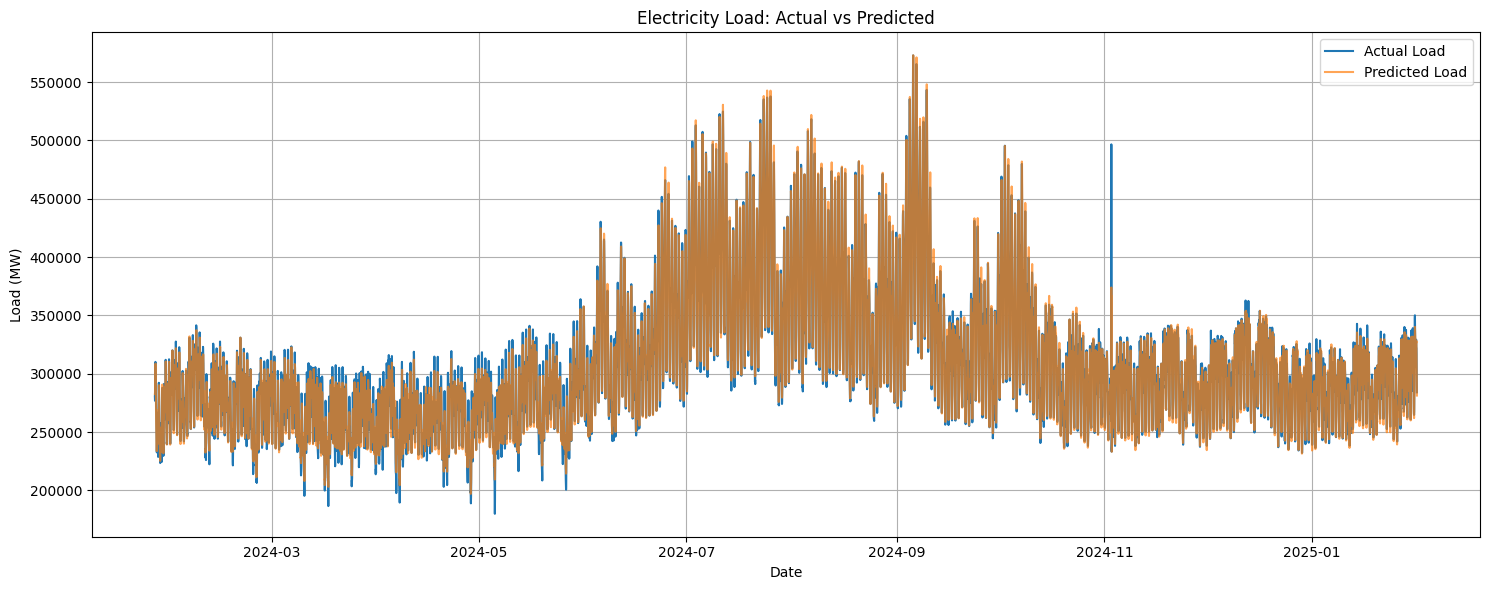

In [9]:
# Visualize the results
if not results.empty:
    plt.figure(figsize=(15, 6))
    plt.plot(results['ds'], results['actual'], label='Actual Load')
    plt.plot(results['ds'], results['predicted'], label='Predicted Load', alpha=0.7)
    plt.title('Electricity Load: Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Load (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No data available for visualization.")

In [10]:
# Component Visualizations with Real Load Values

<Figure size 2000x1000 with 0 Axes>

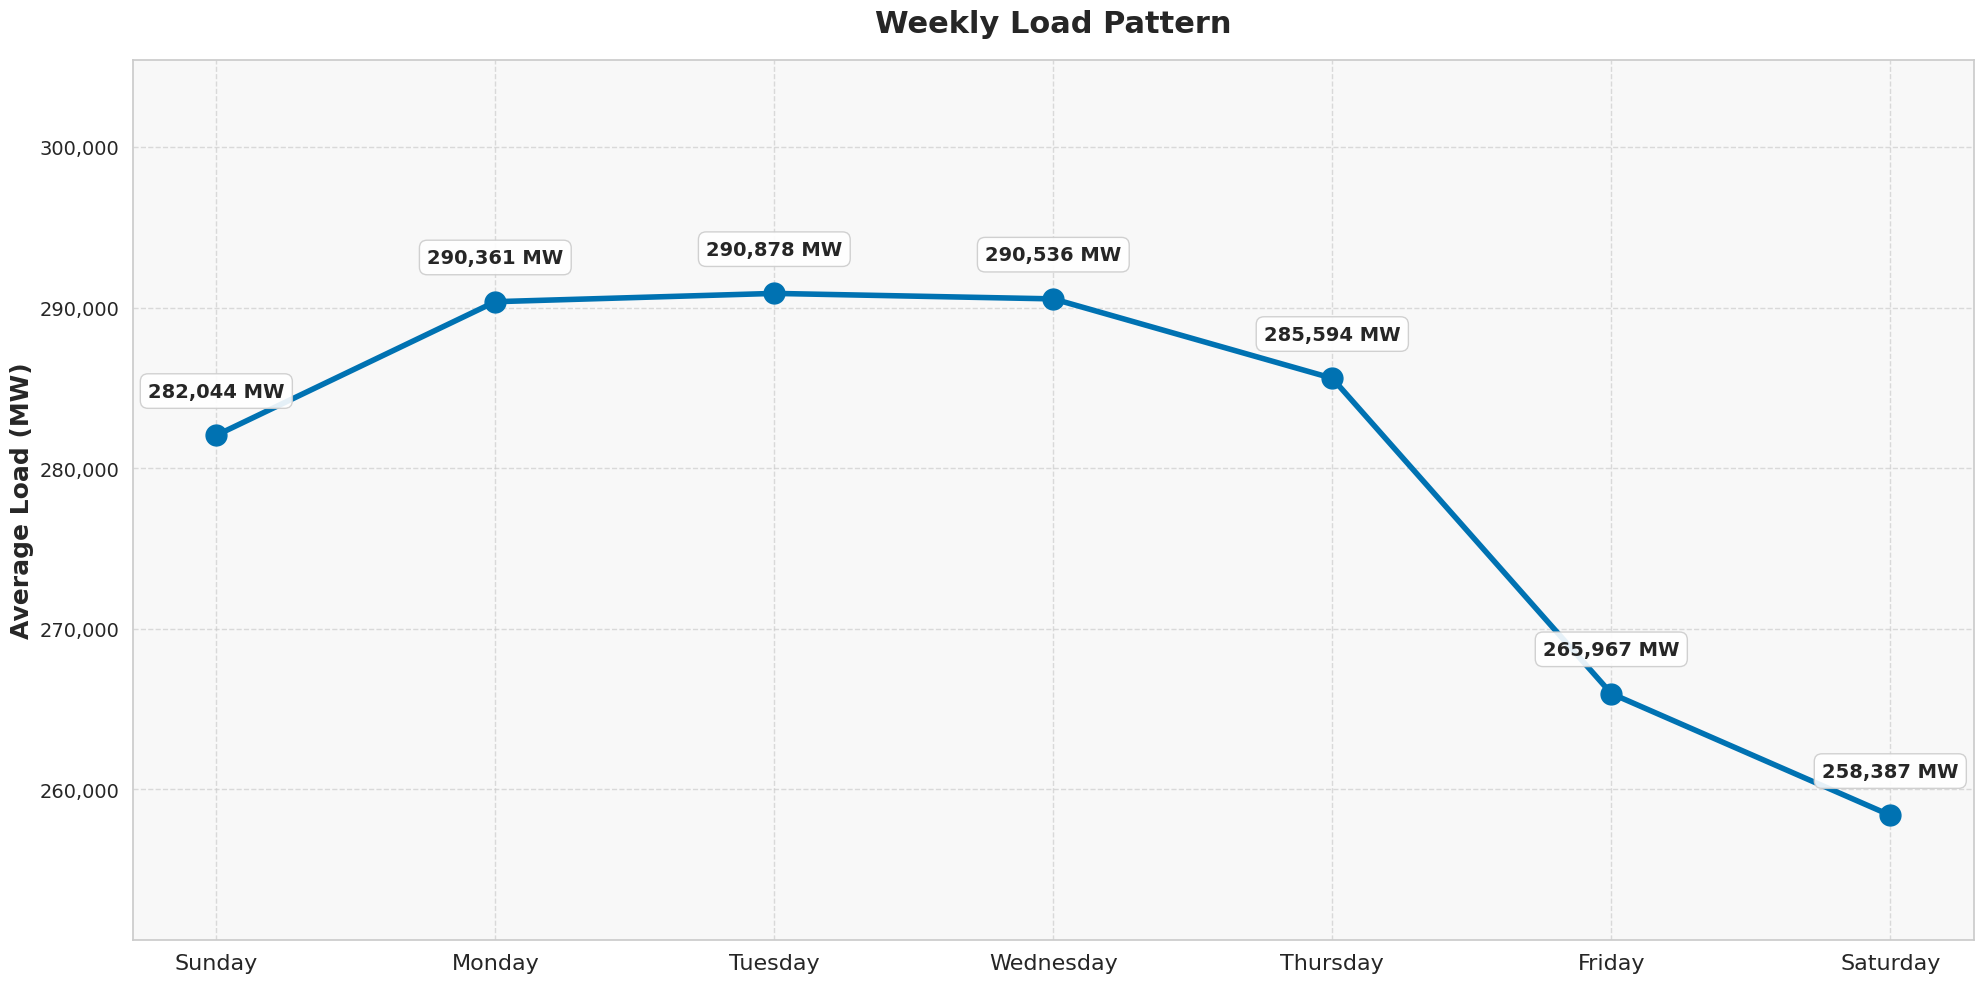

In [50]:
# Weekly Component (using actual load values) with improved visualization
plt.figure(figsize=(20, 10))

days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_numbers = forecast['ds'].dt.dayofweek

# Calculate the baseline trend value
trend_baseline = forecast['trend'].mean()

weekly_effect = pd.DataFrame()
weekly_effect['dow'] = day_numbers
weekly_effect['y'] = forecast['weekly']

# Group by day of week and calculate the mean weekly component
grouped_weekly = weekly_effect.groupby('dow').mean()
sorted_days = sorted(grouped_weekly.index)

# Plot the weekly seasonality as absolute values (trend + weekly effect)
absolute_weekly = [trend_baseline + grouped_weekly.loc[i, 'y'] for i in sorted_days]

# Create a more visually appealing plot with better spacing
fig, ax = plt.subplots(figsize=(20, 10))

# Add grid with light color and dashed lines for better readability
ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
ax.set_axisbelow(True)  # Place grid behind the plot

# Plot the line with enhanced styling
ax.plot(range(7), absolute_weekly, marker='o', markersize=15, linewidth=4, color='#0072B2')

# Customize the plot appearance
ax.set_facecolor('#F8F8F8')  # Light background
for spine in ax.spines.values():
    spine.set_color('#CCCCCC')  # Lighter border

# Add value labels with improved positioning
for i, value in enumerate(absolute_weekly):
    # Format to integer with comma thousand separator
    formatted_value = f"{int(value):,} MW"
    ax.annotate(formatted_value,
                (i, value),
                textcoords="offset points",
                xytext=(0, 25),  # Increase vertical offset
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=14,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9))

# Set axis labels and title with improved styling
ax.set_title('Weekly Load Pattern', fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels([days[i] for i in sorted_days], fontsize=16)
ax.tick_params(axis='y', labelsize=14)

# Set y-axis limits with some padding to accommodate labels
y_min = min(absolute_weekly) * 0.97  # 3% padding below min value
y_max = max(absolute_weekly) * 1.05  # 5% padding above max value
ax.set_ylim([y_min, y_max])

# Format y-axis with comma separator for thousands
from matplotlib.ticker import FuncFormatter
def thousands_formatter(x, pos):
    return f"{int(x):,}"
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

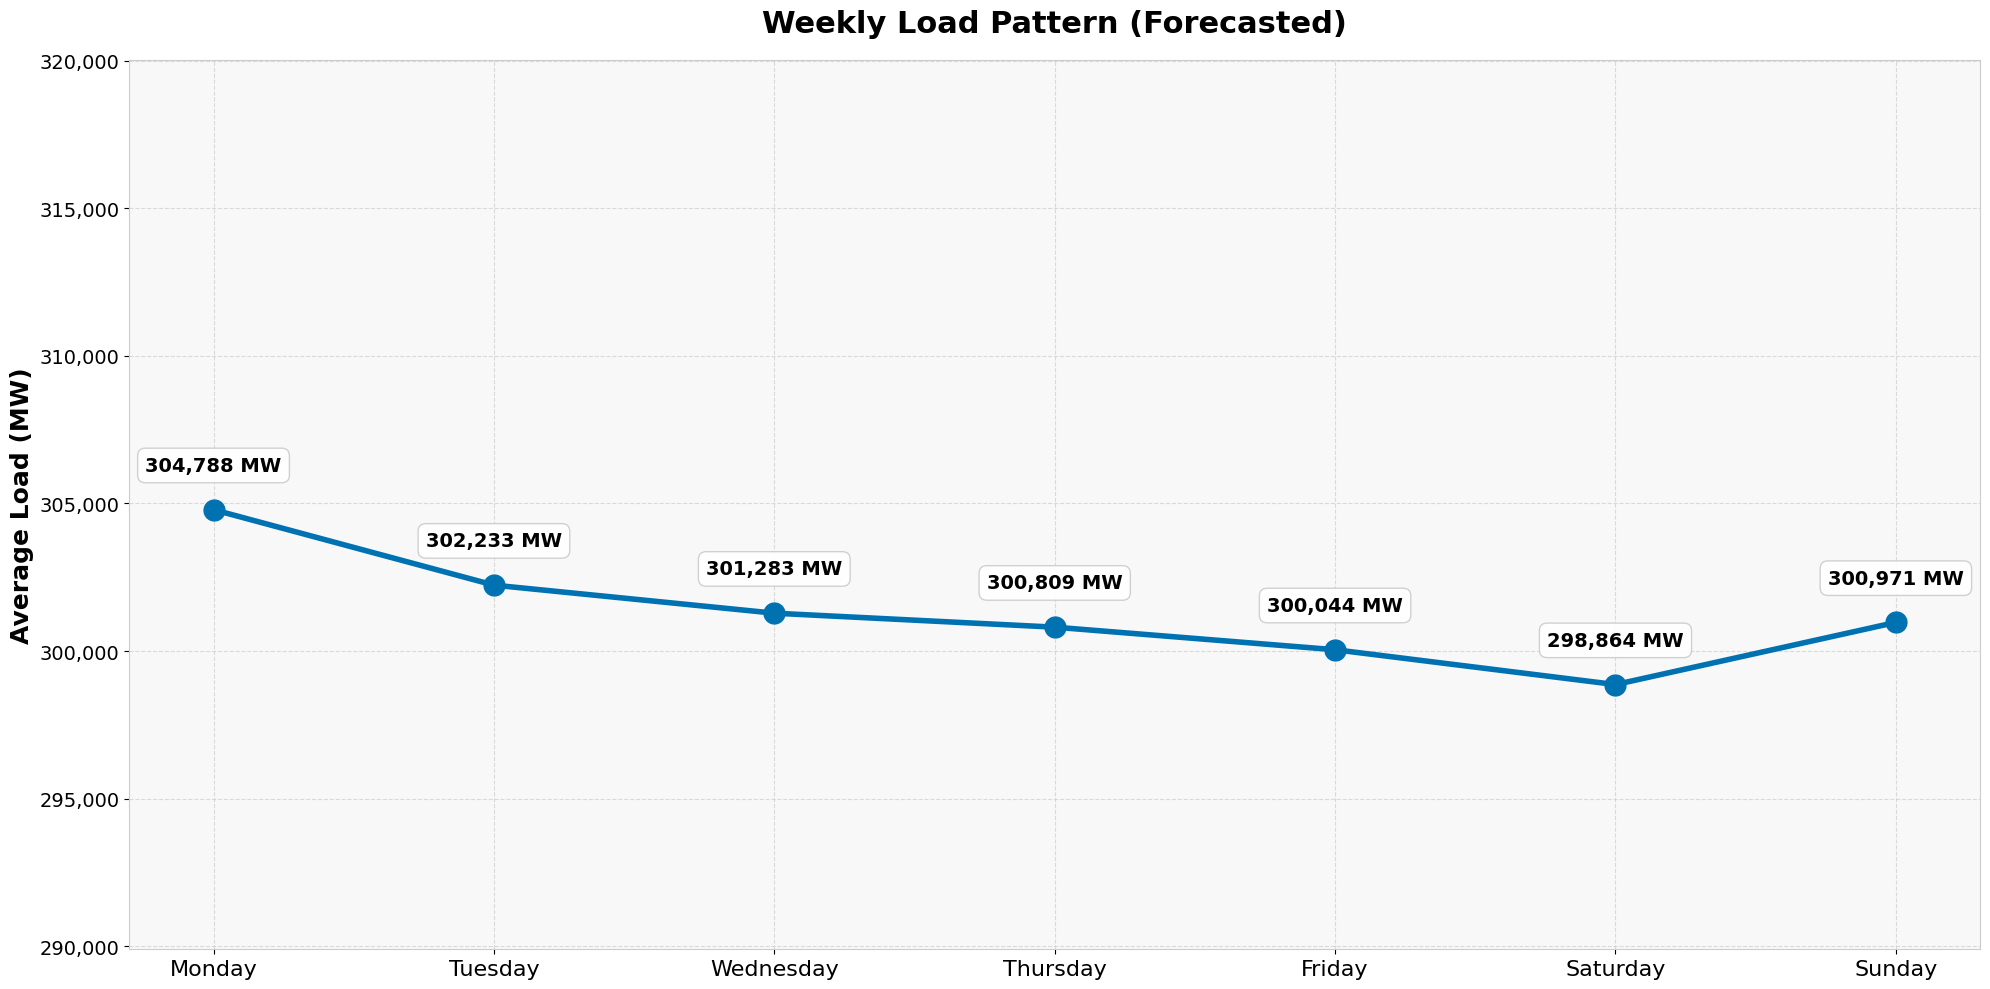

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# 1. Make sure forecast has necessary components
if 'weekly' in forecast.columns and 'trend' in forecast.columns:

    # 2. Prepare Data
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    forecast['dow'] = forecast['ds'].dt.dayofweek  # 0 = Monday

    # 3. Compute trend baseline
    trend_baseline = forecast['trend'].mean()

    # 4. Build weekly effect DataFrame
    weekly_effect = forecast[['dow', 'weekly']].copy()
    grouped_weekly = weekly_effect.groupby('dow').mean()
    sorted_days = sorted(grouped_weekly.index)

    # 5. Calculate absolute expected weekly values (trend + seasonality)
    absolute_weekly = [trend_baseline + grouped_weekly.loc[i, 'weekly'] for i in sorted_days]

    # 6. Plot
    fig, ax = plt.subplots(figsize=(20, 10))
    ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    ax.set_axisbelow(True)
    ax.set_facecolor('#F8F8F8')

    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')

    ax.plot(range(7), absolute_weekly, marker='o', markersize=15, linewidth=4, color='#0072B2')

    # 7. Annotate values on plot
    for i, value in enumerate(absolute_weekly):
        formatted_value = f"{int(value):,} MW"
        ax.annotate(
            formatted_value,
            (i, value),
            textcoords="offset points",
            xytext=(0, 25),
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9)
        )

    # 8. Set titles and labels
    ax.set_title('Weekly Load Pattern (Forecasted)', fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
    ax.set_xticks(range(7))
    ax.set_xticklabels([days[i] for i in sorted_days], fontsize=16)
    ax.tick_params(axis='y', labelsize=14)

    # 9. Y-axis formatting
    y_min = min(absolute_weekly) * 0.97
    y_max = max(absolute_weekly) * 1.05
    ax.set_ylim([y_min, y_max])

    def thousands_formatter(x, pos):
        return f"{int(x):,}"
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    plt.tight_layout()
    plt.show()

else:
    print("Forecast data does not include 'weekly' or 'trend' component.")


In [52]:
# Weekly Load Pattern Analysis

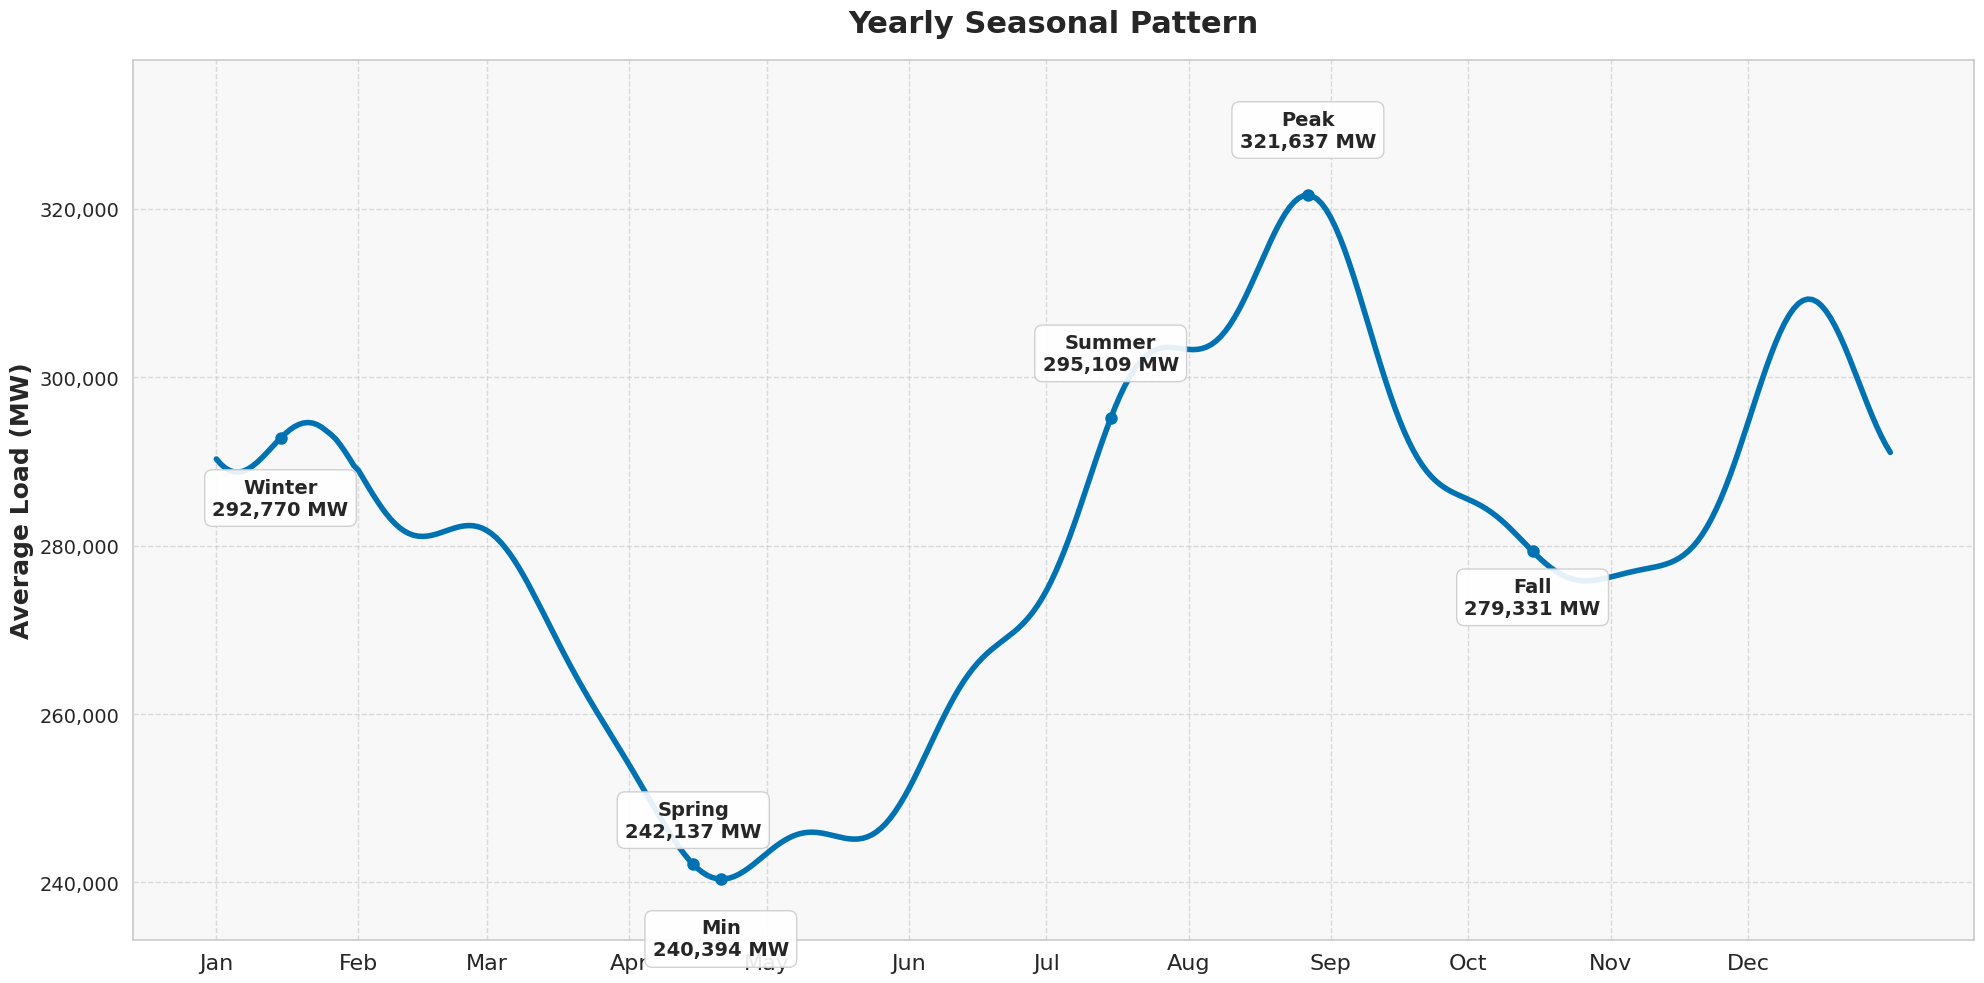

In [51]:
# Yearly Component with improved visualization
if 'yearly' in forecast.columns:
    # Group by day of year
    yearly_effect = pd.DataFrame()
    yearly_effect['doy'] = forecast['ds'].dt.dayofyear
    yearly_effect['y'] = forecast['yearly']

    # Aggregate by day of year
    grouped_yearly = yearly_effect.groupby('doy').mean()
    days_of_year = sorted(grouped_yearly.index)

    # Plot absolute values (trend + yearly effect)
    absolute_yearly = [trend_baseline + grouped_yearly.loc[d, 'y'] for d in days_of_year]

    # Create enhanced visualization
    fig, ax = plt.subplots(figsize=(20, 10))

    # Add grid with light color and dashed lines
    ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    ax.set_axisbelow(True)  # Place grid behind the plot

    # Set background and border
    ax.set_facecolor('#F8F8F8')  # Light background
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')  # Lighter border

    # Plot the line with enhanced styling
    ax.plot(days_of_year, absolute_yearly, linewidth=4, color='#0072B2')

    # Calculate key points to annotate
    peak_idx = absolute_yearly.index(max(absolute_yearly))
    trough_idx = absolute_yearly.index(min(absolute_yearly))

    # Find middle points for each season for additional annotations
    winter_idx = days_of_year.index(15) if 15 in days_of_year else None  # ~ January 15
    spring_idx = days_of_year.index(105) if 105 in days_of_year else None  # ~ April 15
    summer_idx = days_of_year.index(196) if 196 in days_of_year else None  # ~ July 15
    fall_idx = days_of_year.index(288) if 288 in days_of_year else None   # ~ October 15

    # List of key points to annotate
    key_points = [
        (peak_idx, 'Peak'),
        (trough_idx, 'Min'),
        (winter_idx, 'Winter'),
        (spring_idx, 'Spring'),
        (summer_idx, 'Summer'),
        (fall_idx, 'Fall')
    ]

    # Add annotations for key points
    for idx_entry, label in key_points:
        if idx_entry is not None:
            day = days_of_year[idx_entry]
            value = absolute_yearly[idx_entry]

            # Format value with thousand separator
            formatted_value = f"{int(value):,} MW"

            # Alternate vertical position of labels to avoid overlap
            if label in ['Peak', 'Summer']:
                vert_offset = 35
            elif label in ['Min', 'Winter']:
                vert_offset = -55
            else:
                vert_offset = 20 if idx_entry % 2 == 0 else -45

            ax.annotate(
                f'{label}\n{formatted_value}',
                (day, value),
                textcoords="offset points",
                xytext=(0, vert_offset),
                ha='center',
                fontsize=14,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9)
            )

            # Add larger marker at the annotated point
            ax.plot(day, value, 'o', markersize=8, color='#0072B2')

    # Create month labels for x-axis
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Format y-axis with comma separator for thousands
    from matplotlib.ticker import FuncFormatter
    def thousands_formatter(x, pos):
        return f"{int(x):,}"
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Set axis labels and title with improved styling
    ax.set_title('Yearly Seasonal Pattern', fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_names, fontsize=16)
    ax.tick_params(axis='y', labelsize=14)

    # Set y-axis limits with padding to accommodate labels
    y_min = min(absolute_yearly) * 0.97  # 3% padding below min value
    y_max = max(absolute_yearly) * 1.05  # 5% padding above max value
    ax.set_ylim([y_min, y_max])

    plt.tight_layout()
    plt.show()

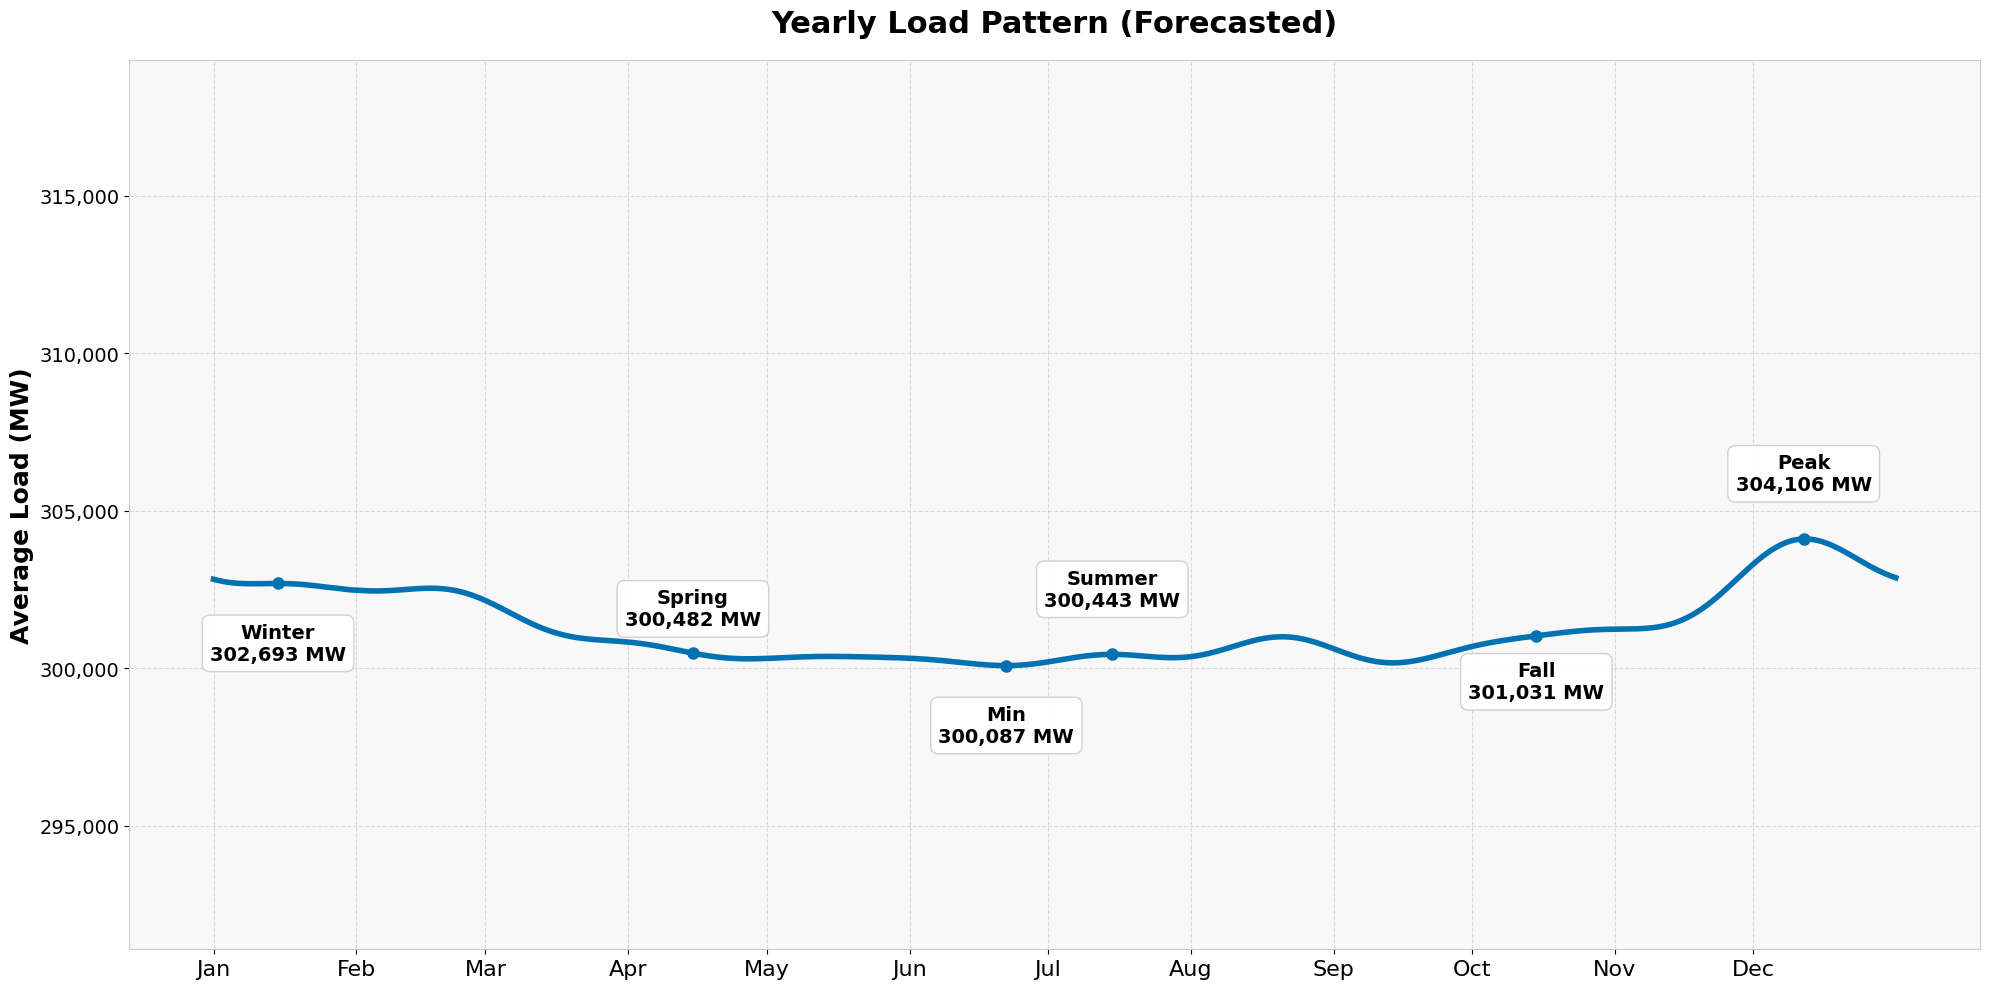

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Check if 'yearly' and 'trend' components are available
if 'yearly' in forecast.columns and 'trend' in forecast.columns:

    # 1. Calculate trend baseline
    trend_baseline = forecast['trend'].mean()

    # 2. Prepare day-of-year and yearly component
    forecast['doy'] = forecast['ds'].dt.dayofyear
    yearly_effect = forecast[['doy', 'yearly']].copy()

    # 3. Group by day of year and calculate mean effect
    grouped_yearly = yearly_effect.groupby('doy').mean()
    days_of_year = sorted(grouped_yearly.index)

    # 4. Calculate absolute load (trend + yearly effect)
    absolute_yearly = [trend_baseline + grouped_yearly.loc[d, 'yearly'] for d in days_of_year]

    # 5. Start plot
    fig, ax = plt.subplots(figsize=(20, 10))
    ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    ax.set_axisbelow(True)
    ax.set_facecolor('#F8F8F8')
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')

    ax.plot(days_of_year, absolute_yearly, linewidth=4, color='#0072B2')

    # 6. Find key points
    peak_idx = absolute_yearly.index(max(absolute_yearly))
    trough_idx = absolute_yearly.index(min(absolute_yearly))

    # Season midpoints (approximate DOY)
    season_indices = {
        'Winter': 15,
        'Spring': 105,
        'Summer': 196,
        'Fall': 288
    }

    key_points = [(peak_idx, 'Peak'), (trough_idx, 'Min')]
    for season, day in season_indices.items():
        if day in days_of_year:
            key_points.append((days_of_year.index(day), season))

    # 7. Annotate key points
    for idx, label in key_points:
        day = days_of_year[idx]
        value = absolute_yearly[idx]
        formatted_value = f"{int(value):,} MW"

        # Alternate vertical offsets
        vert_offset = 35 if label in ['Peak', 'Summer'] else -55 if label in ['Min', 'Winter'] else 20 if idx % 2 == 0 else -45

        ax.annotate(
            f'{label}\n{formatted_value}',
            (day, value),
            textcoords="offset points",
            xytext=(0, vert_offset),
            ha='center',
            fontsize=14,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9)
        )
        ax.plot(day, value, 'o', markersize=8, color='#0072B2')

    # 8. X-axis formatting (month ticks)
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_names, fontsize=16)

    # 9. Y-axis formatting
    def thousands_formatter(x, pos): return f"{int(x):,}"
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)

    # 10. Title & layout
    ax.set_title('Yearly Load Pattern (Forecasted)', fontsize=22, fontweight='bold', pad=20)
    y_min = min(absolute_yearly) * 0.97
    y_max = max(absolute_yearly) * 1.05
    ax.set_ylim([y_min, y_max])

    plt.tight_layout()
    plt.show()

else:
    print("Forecast does not contain 'yearly' or 'trend' component.")


In [53]:
# Yearly Seasonal Pattern Analysis

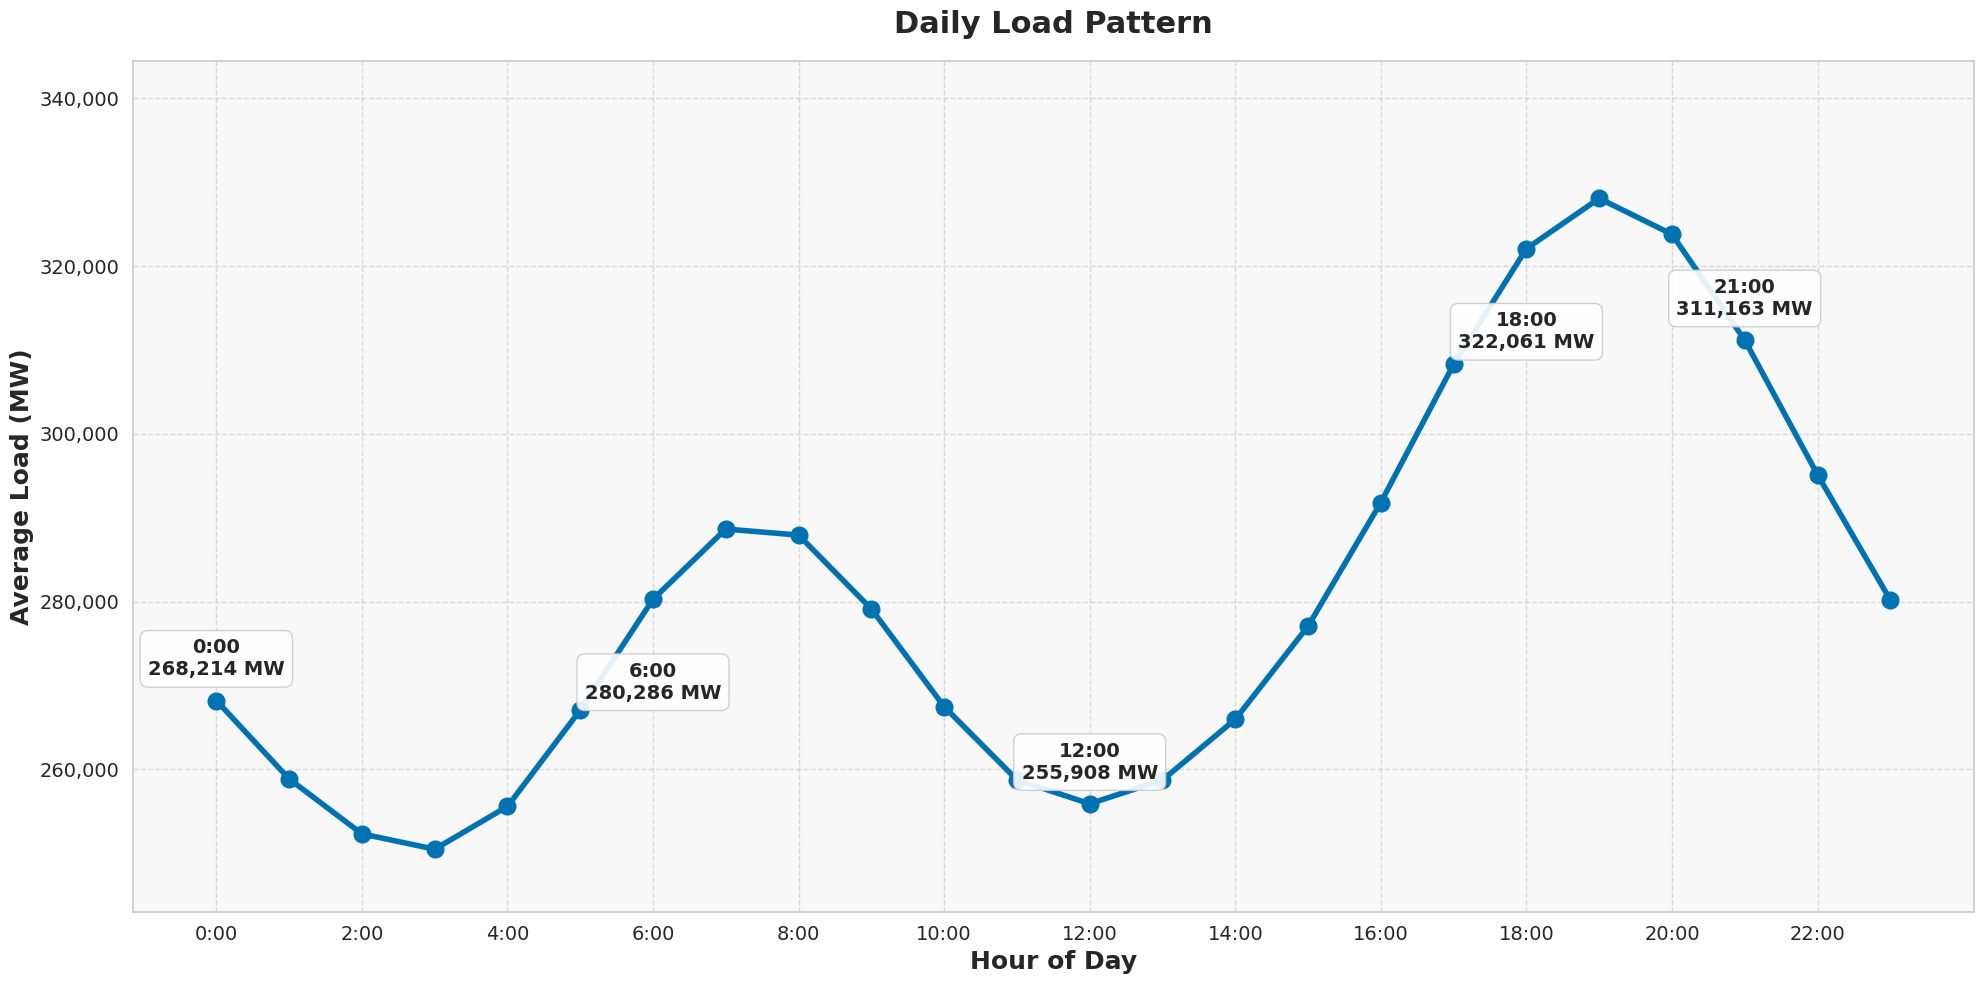

In [54]:
# Daily Component with improved visualization
if 'daily' in forecast.columns:
    # Group by hour of day
    daily_effect = pd.DataFrame()
    daily_effect['hour'] = forecast['ds'].dt.hour
    daily_effect['y'] = forecast['daily']

    # Aggregate by hour
    grouped_daily = daily_effect.groupby('hour').mean()
    hours = sorted(grouped_daily.index)

    # Plot absolute values (trend + daily effect)
    absolute_daily = [trend_baseline + grouped_daily.loc[h, 'y'] for h in hours]

    # Create enhanced visualization
    fig, ax = plt.subplots(figsize=(20, 10))

    # Add grid with light color and dashed lines
    ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    ax.set_axisbelow(True)  # Place grid behind the plot

    # Set background and border
    ax.set_facecolor('#F8F8F8')  # Light background
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')  # Lighter border

    # Plot the line with enhanced styling
    ax.plot(hours, absolute_daily, marker='o', markersize=12, linewidth=4, color='#0072B2')

    # Define additional hours to annotate for a more complete picture
    key_hours = [0, 6, 12, 18, 21]  # Midnight, morning, noon, evening, night

    # Add annotations for key hours with labels that don't overlap
    for hour in key_hours:
        if hour in hours:
            idx = hours.index(hour)
            value = absolute_daily[idx]

            # Format value with thousand separator
            formatted_value = f"{int(value):,} MW"
            time_label = f"{hour}:00"

            # Alternate vertical position of labels to avoid overlap
            vert_offset = 30 if hour in [0, 12, 21] else -45

            ax.annotate(
                f'{time_label}\n{formatted_value}',
                (hour, value),
                textcoords="offset points",
                xytext=(0, vert_offset),
                ha='center',
                va='center' if vert_offset > 0 else 'top',
                fontsize=14,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9)
            )

    # Format y-axis with comma separator for thousands
    from matplotlib.ticker import FuncFormatter
    def thousands_formatter(x, pos):
        return f"{int(x):,}"
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Set axis labels and title with improved styling
    ax.set_title('Daily Load Pattern', fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Hour of Day', fontsize=18, fontweight='bold')

    # Improved x-axis formatting
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 2)], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Set y-axis limits with padding to accommodate labels
    y_min = min(absolute_daily) * 0.97  # 3% padding below min value
    y_max = max(absolute_daily) * 1.05  # 5% padding above max value
    ax.set_ylim([y_min, y_max])

    plt.tight_layout()
    plt.show()

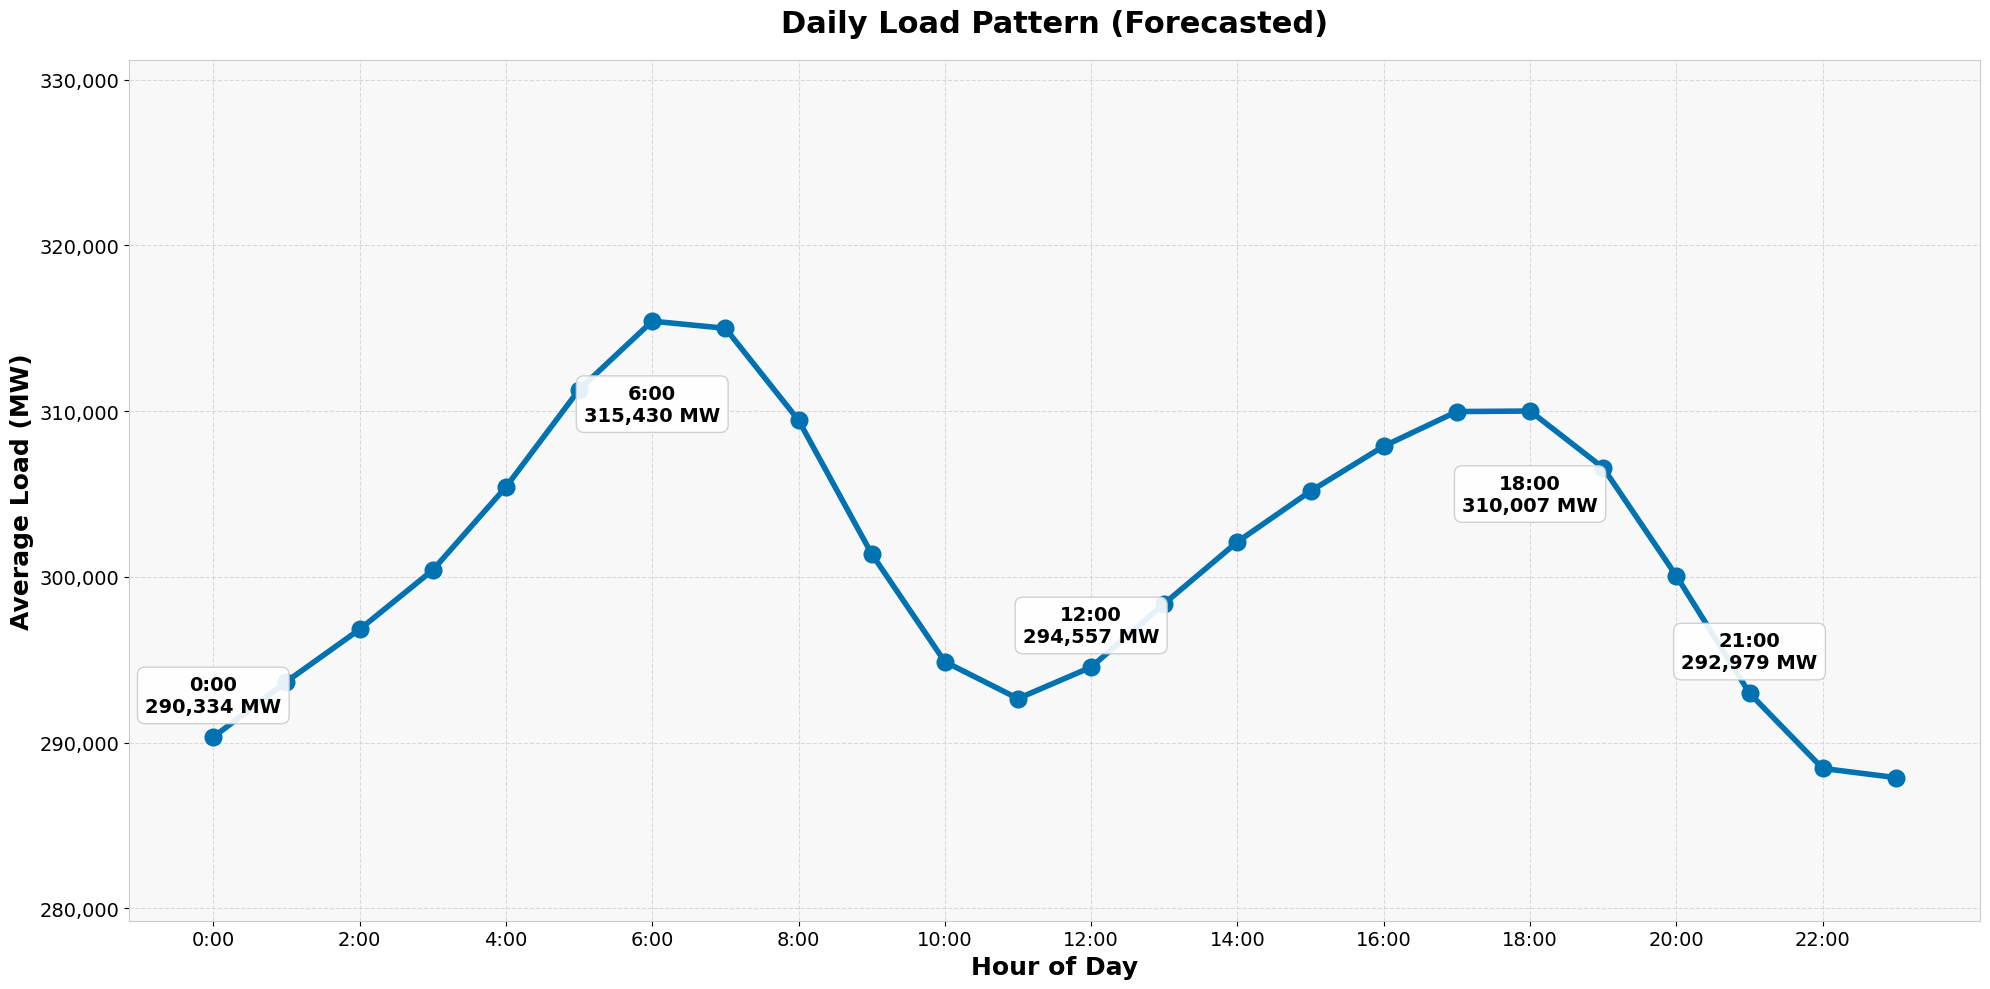

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Check if forecast contains 'daily' and 'trend' component
if 'daily' in forecast.columns and 'trend' in forecast.columns:

    # 1. Calculate trend baseline
    trend_baseline = forecast['trend'].mean()

    # 2. Prepare daily effect data
    forecast['hour'] = forecast['ds'].dt.hour
    daily_effect = forecast[['hour', 'daily']].copy()

    # 3. Group by hour and calculate mean effect
    grouped_daily = daily_effect.groupby('hour').mean()
    hours = sorted(grouped_daily.index)

    # 4. Combine with trend to get total expected load
    absolute_daily = [trend_baseline + grouped_daily.loc[h, 'daily'] for h in hours]

    # 5. Create plot
    fig, ax = plt.subplots(figsize=(20, 10))
    ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    ax.set_axisbelow(True)
    ax.set_facecolor('#F8F8F8')
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')

    ax.plot(hours, absolute_daily, marker='o', markersize=12, linewidth=4, color='#0072B2')

    # 6. Annotate key hours
    key_hours = [0, 6, 12, 18, 21]
    for hour in key_hours:
        if hour in hours:
            value = absolute_daily[hours.index(hour)]
            formatted_value = f"{int(value):,} MW"
            time_label = f"{hour}:00"
            vert_offset = 30 if hour in [0, 12, 21] else -45

            ax.annotate(
                f'{time_label}\n{formatted_value}',
                (hour, value),
                textcoords="offset points",
                xytext=(0, vert_offset),
                ha='center',
                va='center' if vert_offset > 0 else 'top',
                fontsize=14,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9)
            )

    # 7. Format axes
    def thousands_formatter(x, pos): return f"{int(x):,}"
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    ax.set_title('Daily Load Pattern (Forecasted)', fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Hour of Day', fontsize=18, fontweight='bold')

    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 2)], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # 8. Set y-limits with padding
    y_min = min(absolute_daily) * 0.97
    y_max = max(absolute_daily) * 1.05
    ax.set_ylim([y_min, y_max])

    plt.tight_layout()
    plt.show()

else:
    print("Forecast does not contain 'daily' or 'trend' component.")

In [55]:
# Daily Load Pattern Analysis

In [57]:
#Component Visualization Summary

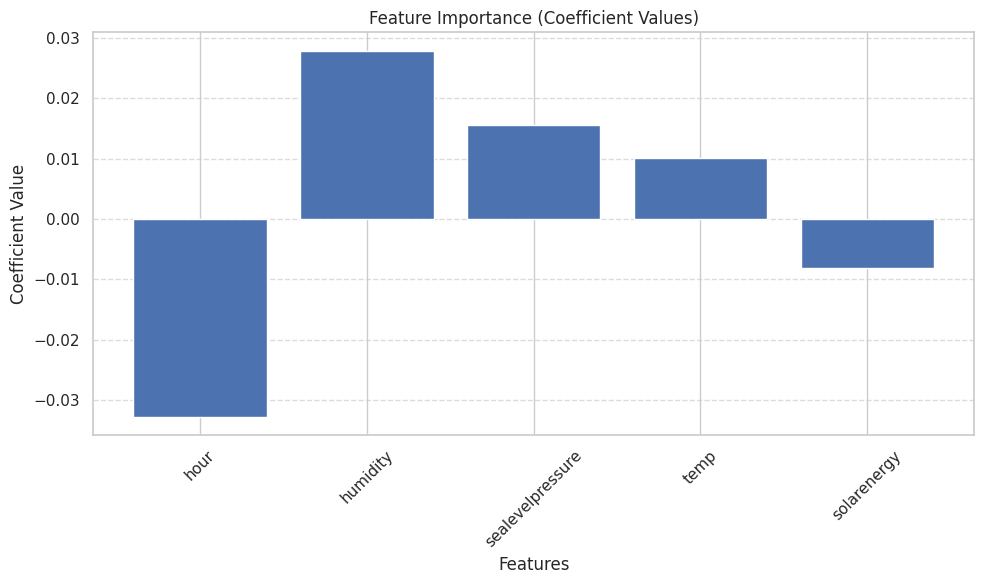

,feature,coefficient,abs_coefficient
0,hour,-0.032773,0.032773
2,humidity,0.027935,0.027935
3,sealevelpressure,0.015572,0.015572
1,temp,0.010128,0.010128
4,solarenergy,-0.008118,0.008118


In [58]:
# Analyze feature importance by examining the coefficients
feature_importance = pd.DataFrame()
feature_importance['feature'] = features
feature_importance['coefficient'] = [model.params['beta'].flatten()[i] for i in range(len(features))]

# Sort by absolute value of coefficient
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance.sort_values('abs_coefficient', ascending=False, inplace=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['coefficient'])
plt.title('Feature Importance (Coefficient Values)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

feature_importance

In [15]:
used_features = model.extra_regressors.keys()


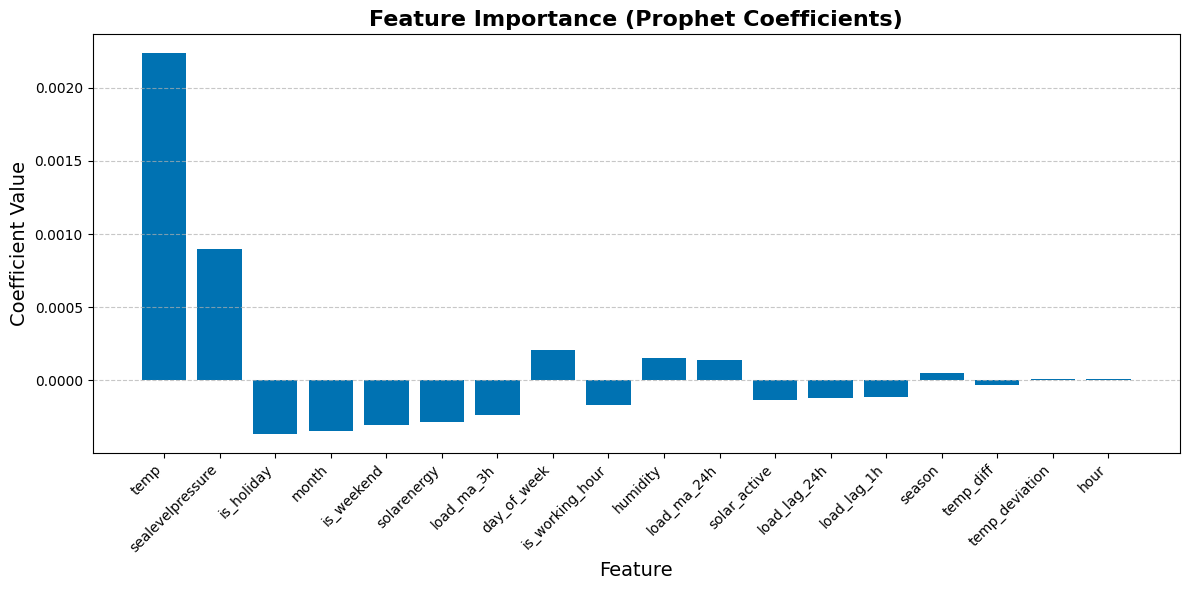

,feature,coefficient,abs_coefficient
1,temp,0.002235,0.002235
3,sealevelpressure,0.000895,0.000895
10,is_holiday,-0.000366,0.000366
8,month,-0.000349,0.000349
6,is_weekend,-0.000304,0.000304
4,solarenergy,-0.000284,0.000284
13,load_ma_3h,-0.000238,0.000238
5,day_of_week,0.000209,0.000209
7,is_working_hour,-0.000169,0.000169
2,humidity,0.000150,0.000150


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Safely get the features that were actually used by Prophet
used_features = list(model.extra_regressors.keys())

# 2. Get the corresponding coefficients from Prophet
coefficients = model.params['beta'].flatten()[:len(used_features)]  # just to be extra safe

# 3. Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': used_features,
    'coefficient': coefficients
})

# 4. Add absolute values for sorting
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance.sort_values('abs_coefficient', ascending=False, inplace=True)

# 5. Plot
plt.figure(figsize=(12, 6))
plt.bar(feature_importance['feature'], feature_importance['coefficient'], color='#0072B2')
plt.title('Feature Importance (Prophet Coefficients)', fontsize=16, fontweight='bold')
plt.xlabel('Feature', fontsize=14)
plt.ylabel('Coefficient Value', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Display DataFrame
feature_importance


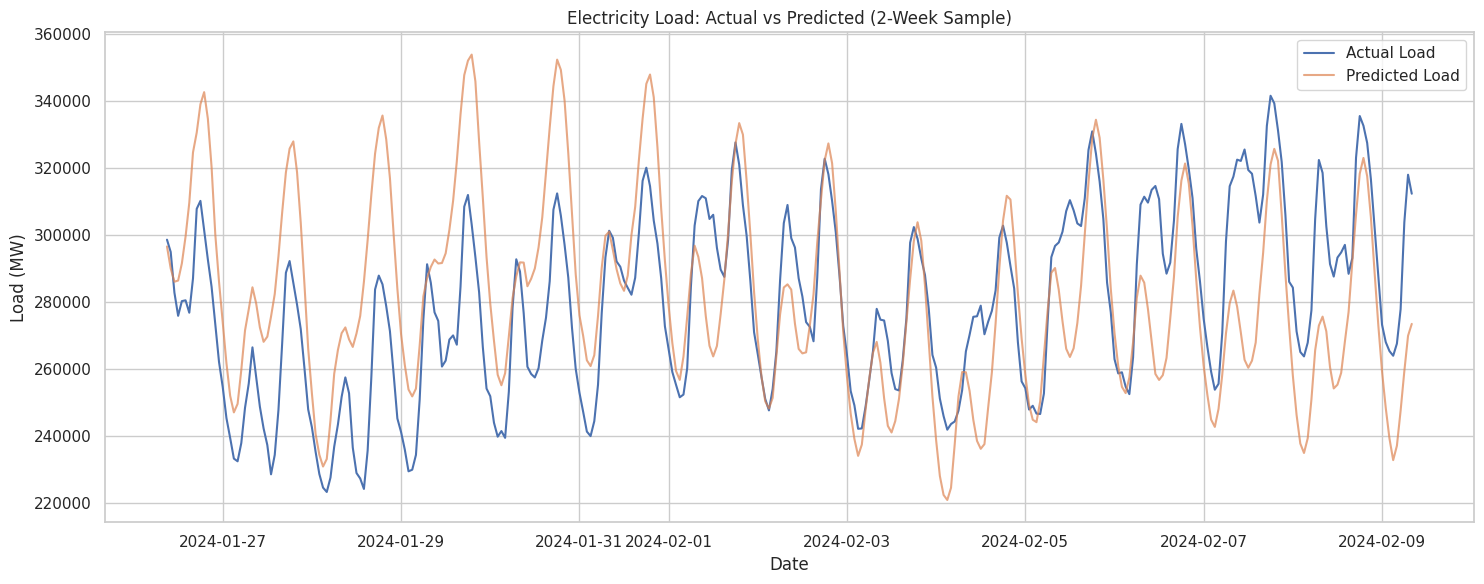

In [59]:
# Zoom in on a specific time period to see detailed predictions
if not results.empty and len(results) >= 24:
    # Select the first 2 weeks of data (or as much as available)
    sample_size = min(336, len(results))  # 14 days * 24 hours
    sample_period = results.iloc[:sample_size]

    plt.figure(figsize=(15, 6))
    plt.plot(sample_period['ds'], sample_period['actual'], label='Actual Load')
    plt.plot(sample_period['ds'], sample_period['predicted'], label='Predicted Load', alpha=0.7)
    plt.title('Electricity Load: Actual vs Predicted (2-Week Sample)')
    plt.xlabel('Date')
    plt.ylabel('Load (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for sample period visualization.")

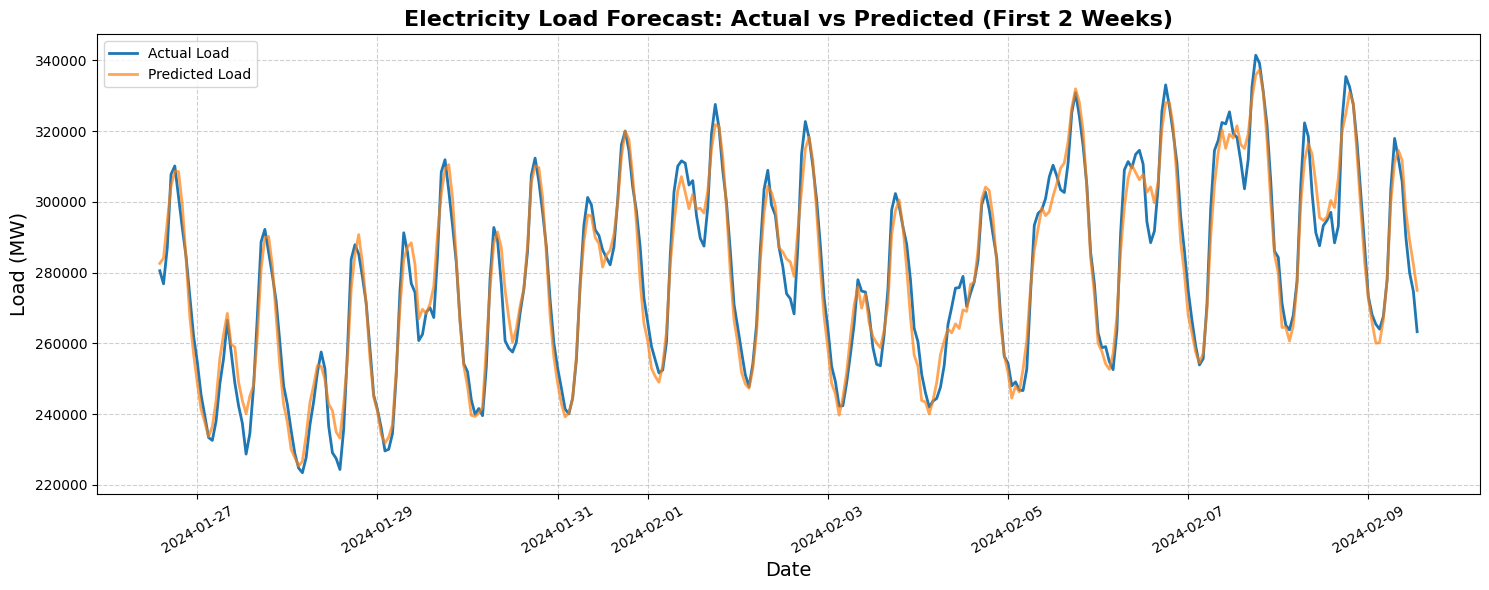

In [17]:
# Zoom in on first 2 weeks of predictions
if not results.empty and len(results) >= 24:
    sample_size = min(336, len(results))  # 14 days * 24 hours
    sample_period = results.iloc[:sample_size]

    # Plot actual vs predicted for this period
    plt.figure(figsize=(15, 6))
    plt.plot(sample_period['ds'], sample_period['actual'], label='Actual Load', linewidth=2)
    plt.plot(sample_period['ds'], sample_period['predicted'], label='Predicted Load', alpha=0.7, linewidth=2)

    plt.title('Electricity Load Forecast: Actual vs Predicted (First 2 Weeks)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Load (MW)', fontsize=14)
    plt.xticks(rotation=30)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Not enough data available for sample period visualization.")

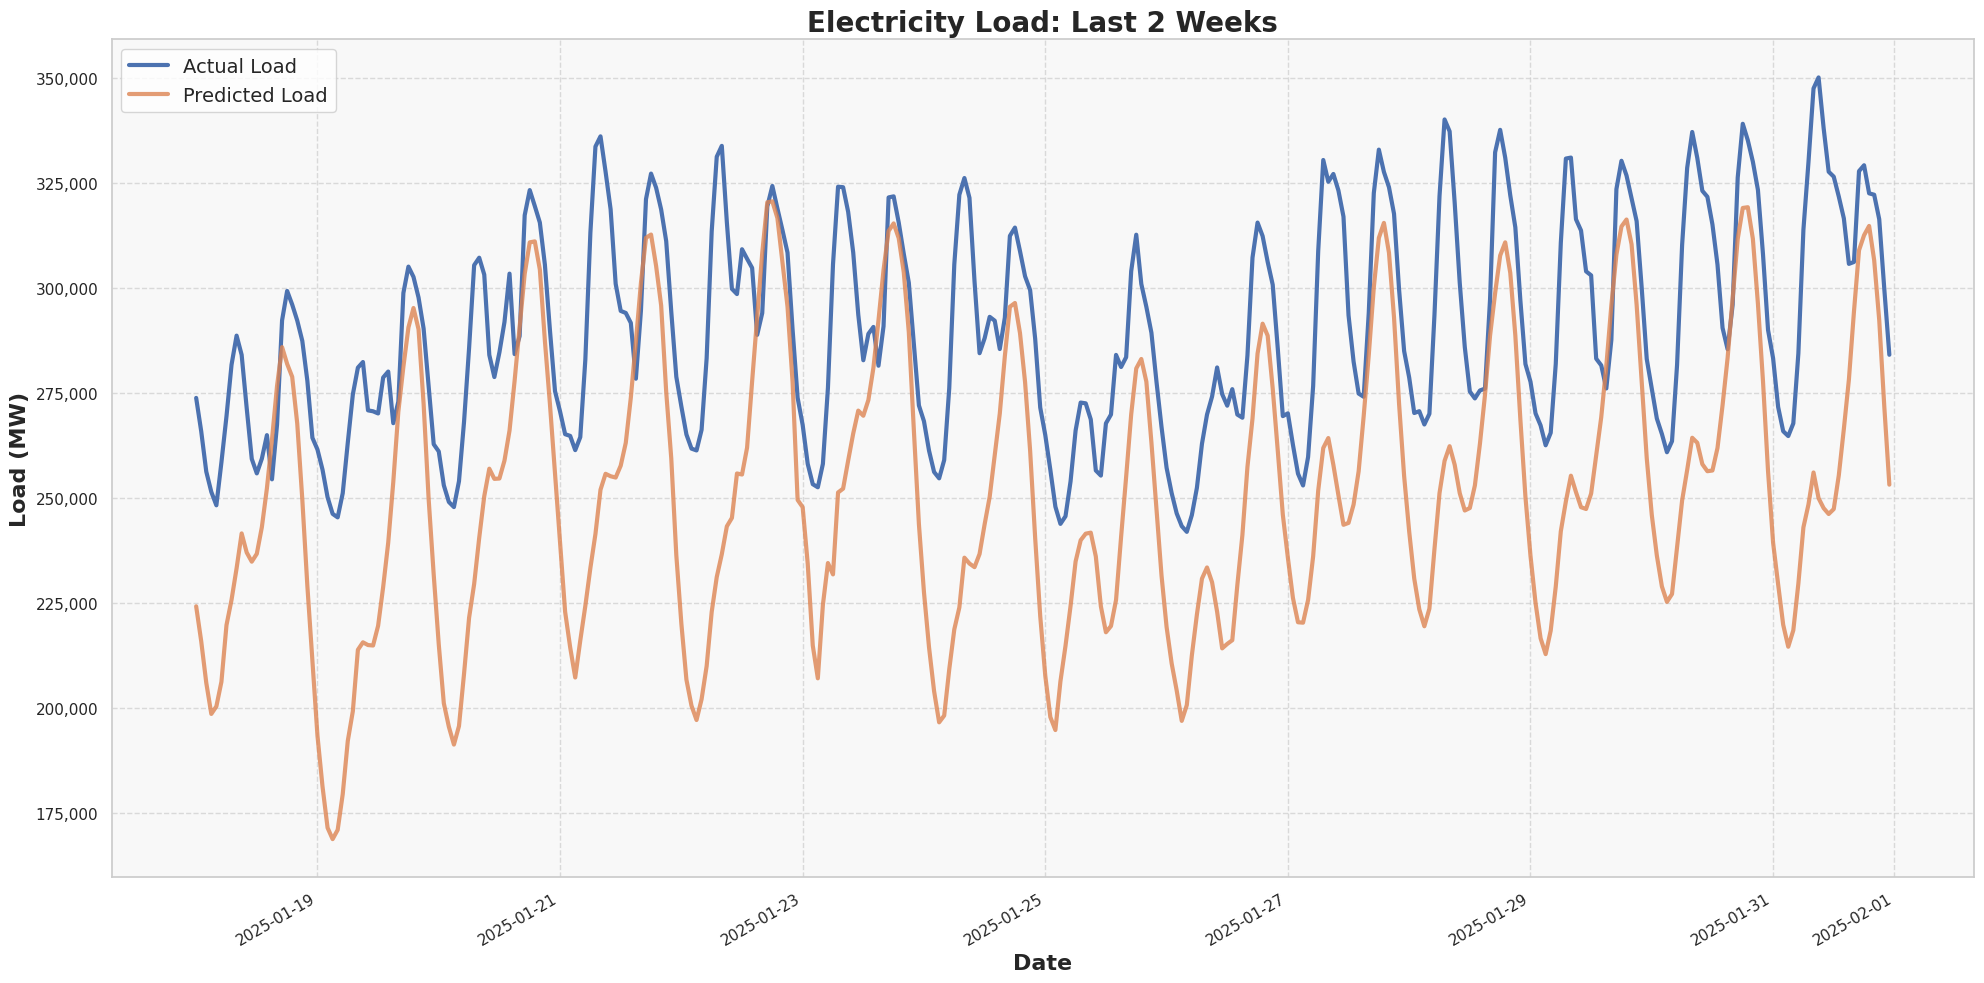

Last 2 Weeks - Mean Absolute Error (MAE): 39440.55 MW
Last 2 Weeks - Root Mean Squared Error (RMSE): 45630.32 MW
Last 2 Weeks - Mean Absolute Percentage Error (MAPE): 13.66%


In [60]:
# Get the last 2 weeks of data and compare actual vs. predicted
if not results.empty and len(results) >= 24:
    # Select the last 2 weeks of data
    hours_in_two_weeks = 14 * 24  # 14 days * 24 hours
    last_two_weeks = results.iloc[-hours_in_two_weeks:].reset_index(drop=True)

    # Create visualization with larger figure
    plt.figure(figsize=(20, 10))

    # Plot with better styling
    plt.plot(last_two_weeks['ds'], last_two_weeks['actual'], label='Actual Load', linewidth=3)
    plt.plot(last_two_weeks['ds'], last_two_weeks['predicted'], label='Predicted Load', linewidth=3, alpha=0.8)

    # Calculate error metrics for this period
    last_2w_mae = mean_absolute_error(last_two_weeks['actual'], last_two_weeks['predicted'])
    last_2w_rmse = np.sqrt(mean_squared_error(last_two_weeks['actual'], last_two_weeks['predicted']))
    last_2w_mape = np.mean(np.abs((last_two_weeks['actual'] - last_two_weeks['predicted']) / last_two_weeks['actual'])) * 100

    # Add error metrics to the plot title
    plt.title(f'Electricity Load: Last 2 Weeks', fontsize=20, fontweight='bold')
    plt.xlabel('Date', fontsize=16, fontweight='bold')
    plt.ylabel('Load (MW)', fontsize=16, fontweight='bold')

    # Format y-axis with comma separator for thousands
    from matplotlib.ticker import FuncFormatter
    def thousands_formatter(x, pos):
        return f"{int(x):,}"
    plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Improve legend and grid
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Improve x-axis date formatting
    plt.gcf().autofmt_xdate()

    # Set background and layout
    plt.gca().set_facecolor('#F8F8F8')
    for spine in plt.gca().spines.values():
        spine.set_color('#CCCCCC')

    plt.tight_layout()
    plt.show()

    # Print metrics for this period
    print(f"Last 2 Weeks - Mean Absolute Error (MAE): {last_2w_mae:.2f} MW")
    print(f"Last 2 Weeks - Root Mean Squared Error (RMSE): {last_2w_rmse:.2f} MW")
    print(f"Last 2 Weeks - Mean Absolute Percentage Error (MAPE): {last_2w_mape:.2f}%")
else:
    print("Not enough data for 2-week visualization.")

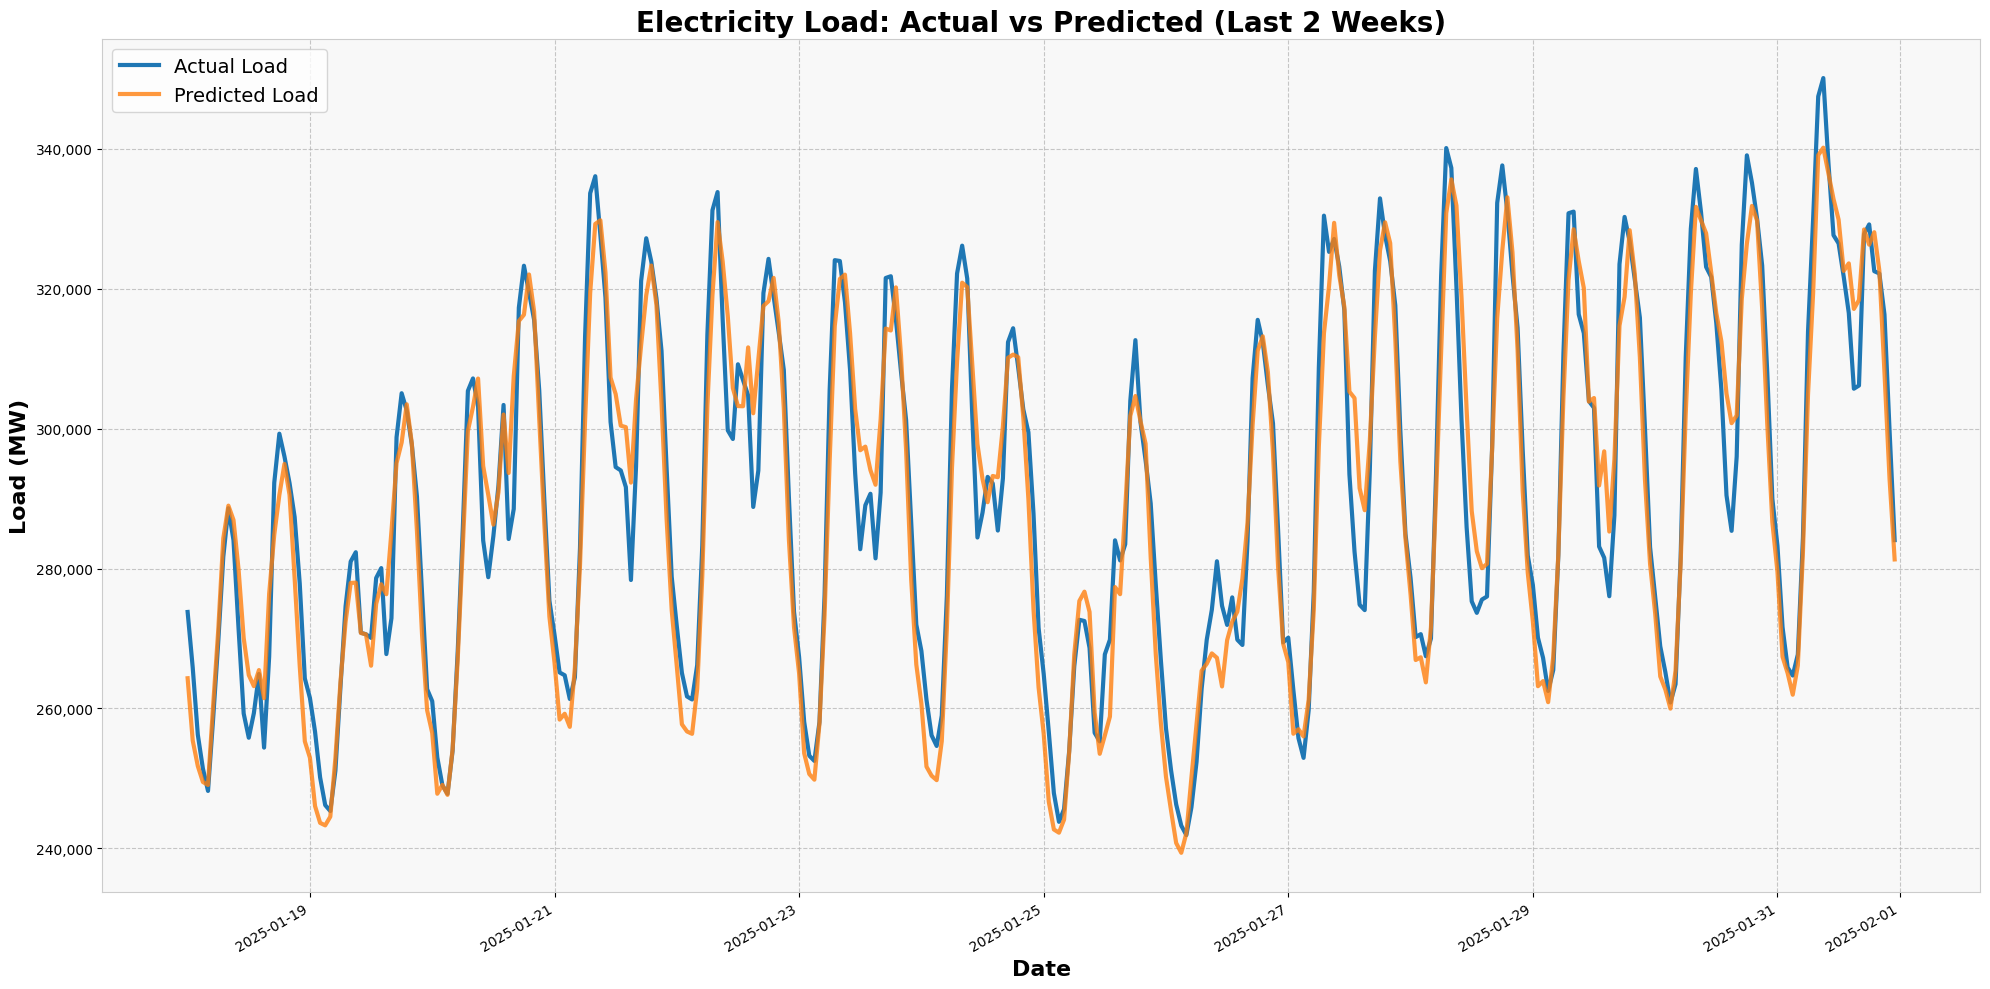

Last 2 Weeks Forecast Evaluation:
Mean Absolute Error (MAE): 5611.35 MW
Root Mean Squared Error (RMSE): 6986.74 MW
Mean Absolute Percentage Error (MAPE): 1.93%


In [18]:
# Safely plot last 2 weeks of forecast vs actual
if not results.empty and len(results) >= 24:
    # Define 2-week window
    hours_in_two_weeks = 14 * 24
    sample_size = min(hours_in_two_weeks, len(results))
    last_two_weeks = results.iloc[-sample_size:].reset_index(drop=True)

    # Create the figure
    plt.figure(figsize=(20, 10))

    # Plot actual and predicted values
    plt.plot(last_two_weeks['ds'], last_two_weeks['actual'], label='Actual Load', linewidth=3)
    plt.plot(last_two_weeks['ds'], last_two_weeks['predicted'], label='Predicted Load', linewidth=3, alpha=0.8)

    # Compute error metrics
    last_2w_mae = mean_absolute_error(last_two_weeks['actual'], last_two_weeks['predicted'])
    last_2w_rmse = np.sqrt(mean_squared_error(last_two_weeks['actual'], last_two_weeks['predicted']))
    last_2w_mape = np.mean(
        np.abs((last_two_weeks['actual'] - last_two_weeks['predicted']) / last_two_weeks['actual'])
    ) * 100

    # Title and axis labels
    plt.title('Electricity Load: Actual vs Predicted (Last 2 Weeks)', fontsize=20, fontweight='bold')
    plt.xlabel('Date', fontsize=16, fontweight='bold')
    plt.ylabel('Load (MW)', fontsize=16, fontweight='bold')

    # Format y-axis ticks with thousands separator
    def thousands_formatter(x, pos): return f"{int(x):,}"
    plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Styling: grid, legend, background, axis
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.gcf().autofmt_xdate()
    ax = plt.gca()
    ax.set_facecolor('#F8F8F8')
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')

    plt.tight_layout()
    plt.show()

    # Display error metrics
    print(f"Last 2 Weeks Forecast Evaluation:")
    print(f"Mean Absolute Error (MAE): {last_2w_mae:.2f} MW")
    print(f"Root Mean Squared Error (RMSE): {last_2w_rmse:.2f} MW")
    print(f"Mean Absolute Percentage Error (MAPE): {last_2w_mape:.2f}%")

else:
    print("Not enough data available for 2-week visualization.")
